In [1]:
import random
import torch

import clip
import utils
import data_utils
import similarity

import matplotlib
from matplotlib import pyplot as plt

/home/s4yadav/private/workspace/CLIP-dissect/clip/clip.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging


## Settings

In [2]:
clip_name = 'ViT-B/16'
target_name = 'resnet50'
target_layer = 'layer4'
d_probe = 'imagenet_broden'
concept_set = 'data/20k.txt'
batch_size = 16
device = 'cuda'
pool_mode = 'avg'

save_dir = 'saved_activations'
similarity_fn = similarity.soft_wpmi

## Run CLIP-Dissect

In [3]:
utils.save_activations(clip_name = clip_name, target_name = target_name, target_layers = [target_layer], 
                       d_probe = d_probe, concept_set = concept_set, batch_size = batch_size, 
                       device = device, pool_mode=pool_mode, save_dir = save_dir)

In [4]:
save_names = utils.get_save_names(clip_name = clip_name, target_name = target_name,
                                  target_layer = target_layer, d_probe = d_probe,
                                  concept_set = concept_set, pool_mode=pool_mode,
                                  save_dir = save_dir)

target_save_name, clip_save_name, text_save_name = save_names

similarities, target_feats = utils.get_similarity_from_activations(target_save_name, clip_save_name, 
                                                             text_save_name, similarity_fn)

with open(concept_set, 'r') as f: 
    words = (f.read()).split('\n')

pil_data = data_utils.get_data(d_probe)

/home/s4yadav/private/workspace/CLIP-dissect/utils.py:153: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  image_features = torch.load(clip_save_name, map_location='cpu').floa

/home/s4yadav/private/workspace/CLIP-dissect/utils.py:162: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  target_feats = torch.load(target_save_name, map_location='cpu')
100%

torch.Size([2048, 20000])


## Visualize Results


 Layer:layer4 Neuron:1587
1st description: sand, sim:0.259
2nd description: gravel, sim:0.241
3rd description: pavement, sim:0.228
5 most highly activating images in D_probe:


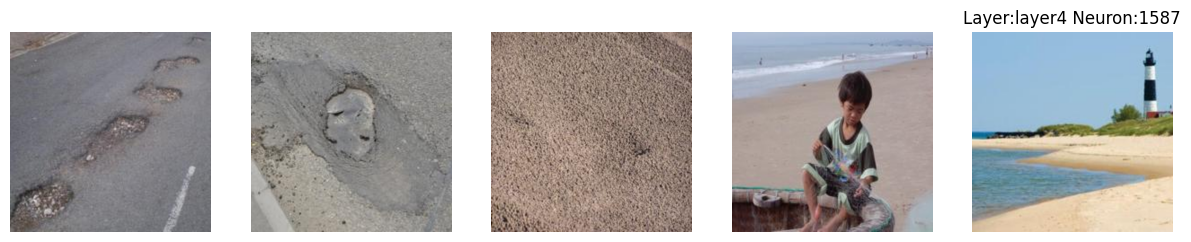


 Layer:layer4 Neuron:208
1st description: basename, sim:0.370
2nd description: deg, sim:0.256
3rd description: hound, sim:0.255
5 most highly activating images in D_probe:


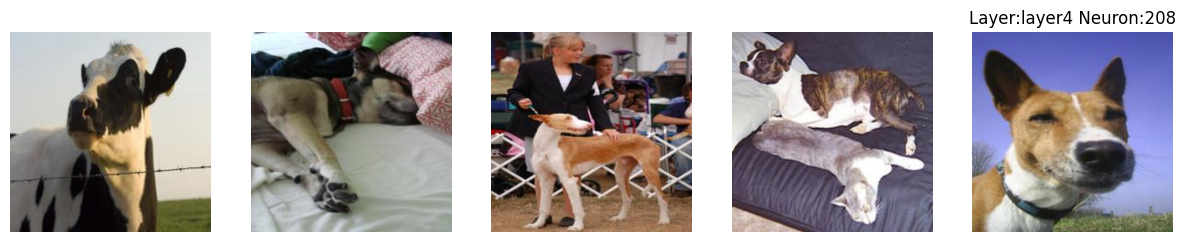


 Layer:layer4 Neuron:214
1st description: saws, sim:0.255
2nd description: dewalt, sim:0.204
3rd description: shear, sim:0.188
5 most highly activating images in D_probe:


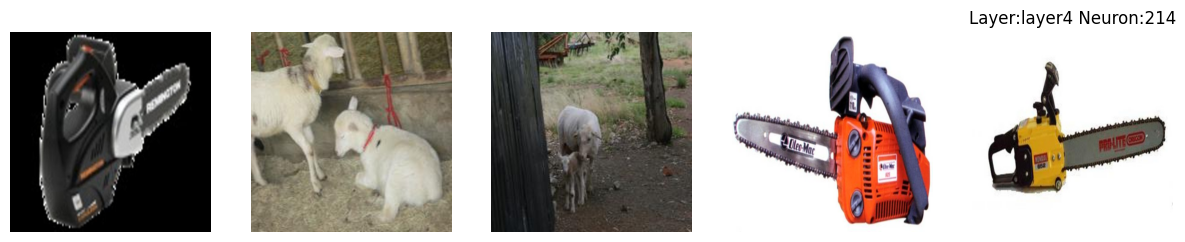


 Layer:layer4 Neuron:155
1st description: workstations, sim:0.375
2nd description: bureau, sim:0.336
3rd description: desks, sim:0.330
5 most highly activating images in D_probe:


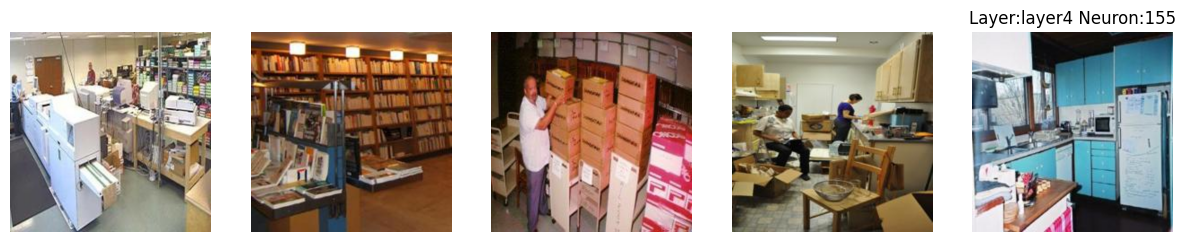


 Layer:layer4 Neuron:1589
1st description: cliffs, sim:0.313
2nd description: geology, sim:0.288
3rd description: canyon, sim:0.280
5 most highly activating images in D_probe:


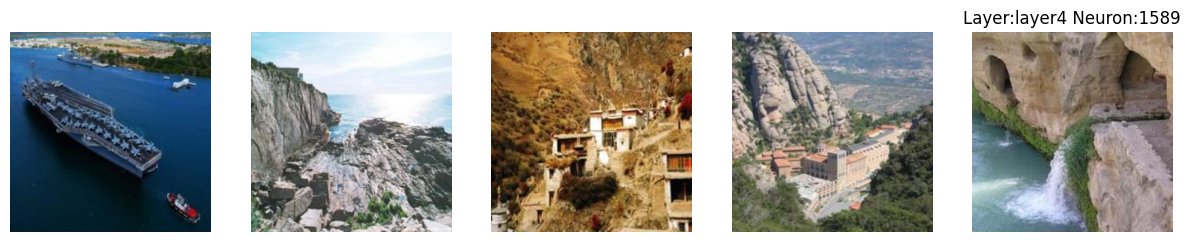


 Layer:layer4 Neuron:1244
1st description: scooter, sim:0.175
2nd description: yamaha, sim:0.169
3rd description: snowmobile, sim:0.166
5 most highly activating images in D_probe:


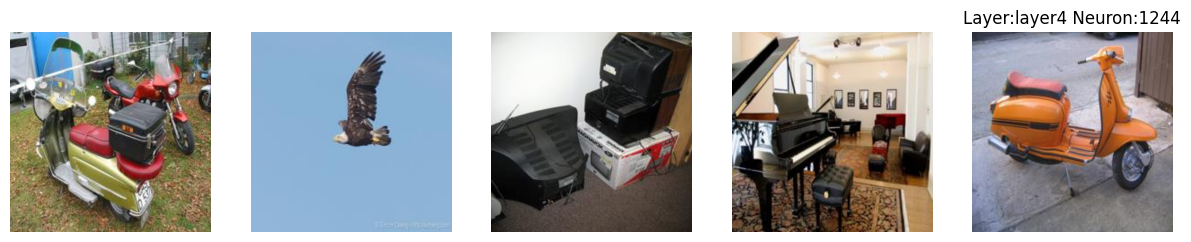


 Layer:layer4 Neuron:314
1st description: textile, sim:0.245
2nd description: cloth, sim:0.223
3rd description: motif, sim:0.201
5 most highly activating images in D_probe:


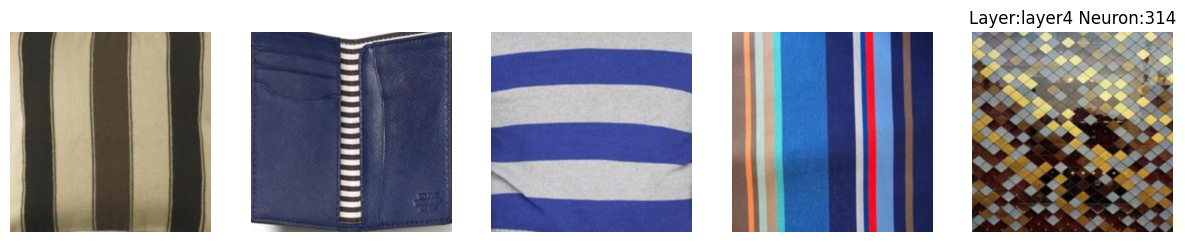


 Layer:layer4 Neuron:560
1st description: meat, sim:0.203
2nd description: pork, sim:0.197
3rd description: meats, sim:0.183
5 most highly activating images in D_probe:


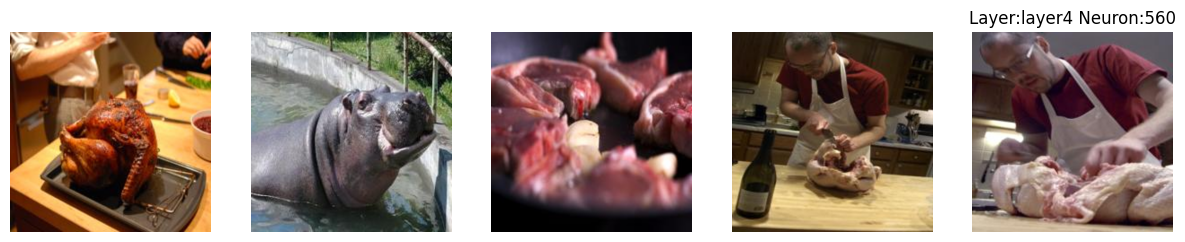


 Layer:layer4 Neuron:1257
1st description: missionaries, sim:0.200
2nd description: earning, sim:0.194
3rd description: missionary, sim:0.191
5 most highly activating images in D_probe:


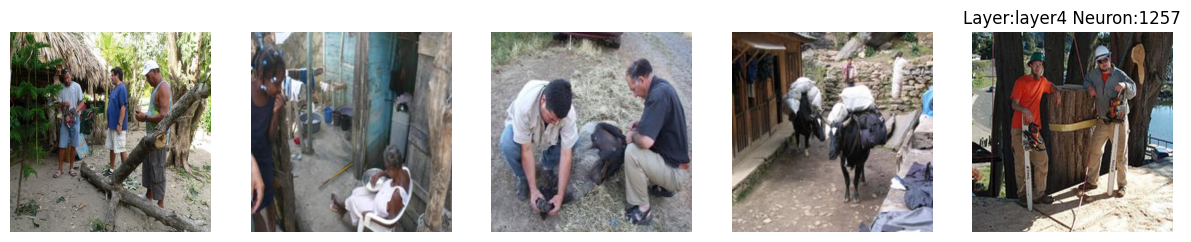


 Layer:layer4 Neuron:95
1st description: birding, sim:0.279
2nd description: birds, sim:0.225
3rd description: wildlife, sim:0.214
5 most highly activating images in D_probe:


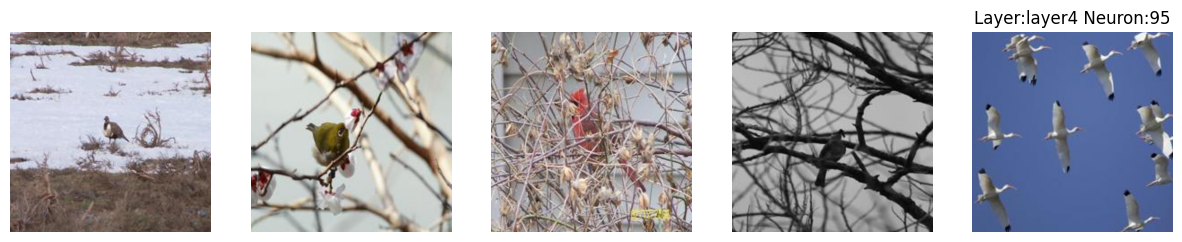

In [5]:
neurons_to_check = ids_to_check = random.sample([i for i in range(target_feats.shape[1])], k=10)
#neurons_to_check = torch.sort(torch.max(similarities, dim=1)[0], descending=True)[1][0:10]

ranks = ["1st", "2nd", "3rd"]
top_vals, top_ids = torch.topk(target_feats, k=5, dim=0)

for orig_id in ids_to_check:

    print('\n Layer:{} Neuron:{}'.format(target_layer, (int(orig_id))))
    vals, ids = torch.topk(similarities[orig_id], k=3, largest=True)
    for i in range(len(vals)):
        print("{} description: {}, sim:{:.3f}".format(ranks[i], words[int(ids[i])], vals[i]))
    
    print("5 most highly activating images in D_probe:")
    fig = plt.figure(figsize=(15, 7))
    for i, top_id in enumerate(top_ids[:, orig_id]):
        im, label = pil_data[top_id]
        im = im.resize([375,375])
        fig.add_subplot(1, 5, i+1)
        plt.imshow(im)
        plt.axis('off')
        
    plt.title('Layer:{} Neuron:{}'.format(target_layer, (int(orig_id))))
    plt.show()

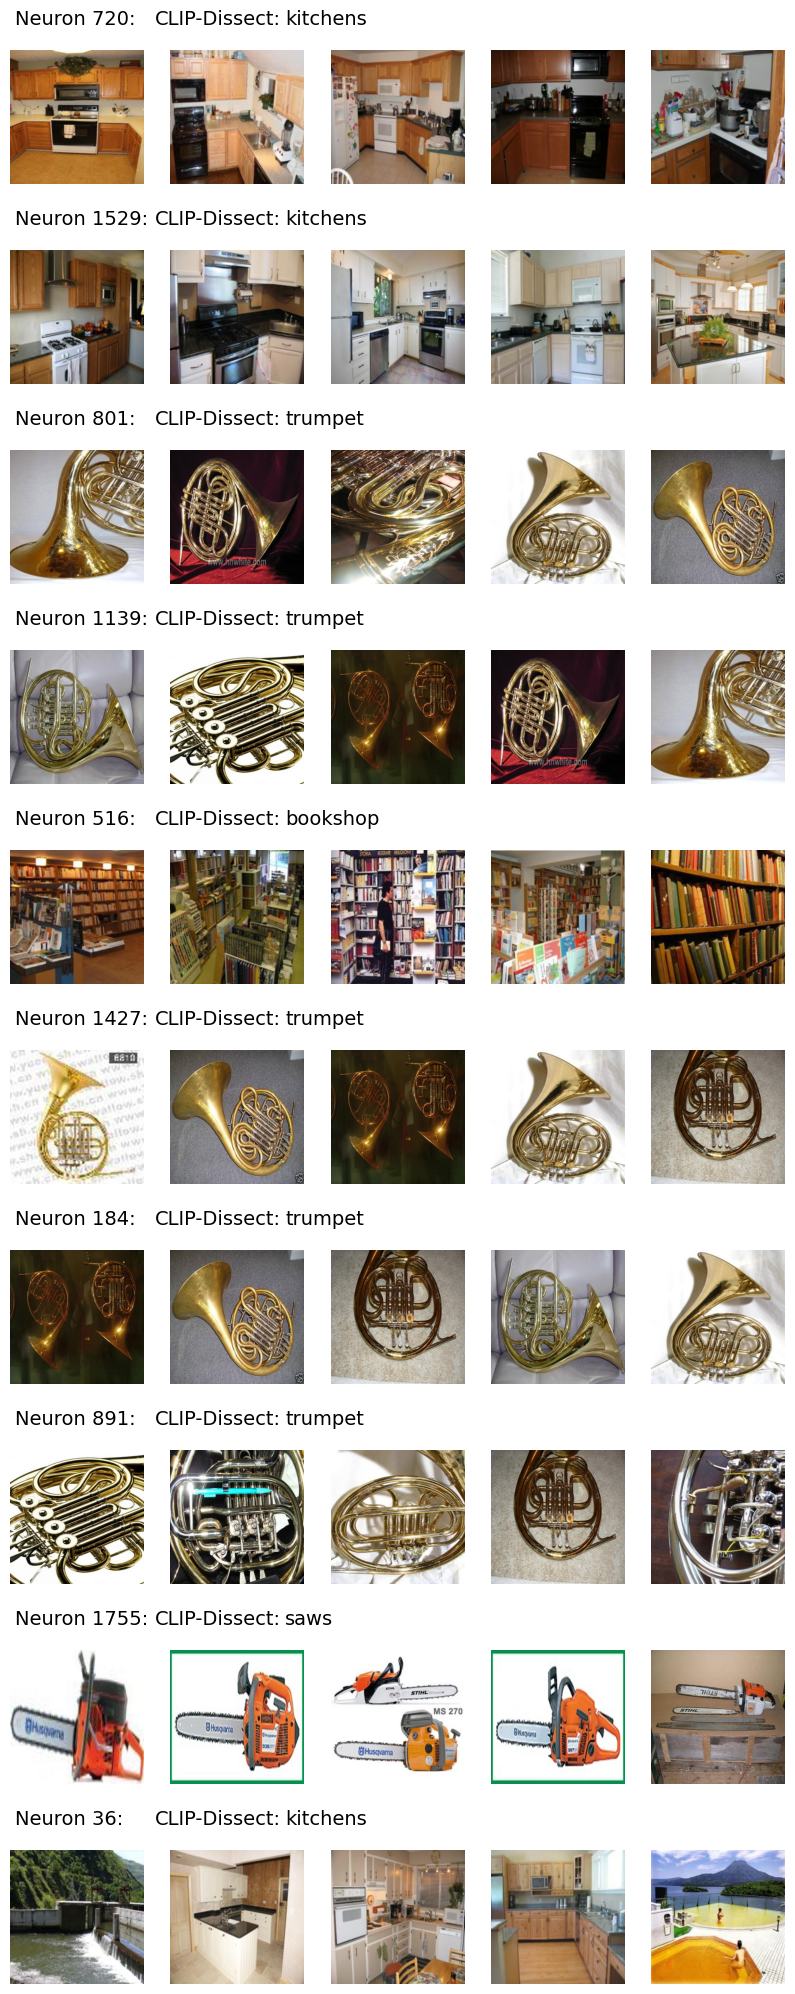

In [6]:
neurons_to_check = torch.sort(torch.max(similarities, dim=1)[0], descending=True)[1][0:10]
font_size=14
font = {'size'   : font_size}

matplotlib.rc('font', **font)

fig = plt.figure(figsize=[10, len(neurons_to_check)*2])#constrained_layout=True)
subfigs = fig.subfigures(nrows=len(neurons_to_check), ncols=1)
for j, orig_id in enumerate(neurons_to_check):
    vals, ids = torch.topk(similarities[orig_id], k=5, largest=True)
        
    subfig = subfigs[j]
    subfig.text(0.13, 0.96, "Neuron {}:".format(int(orig_id)), size=font_size)
    subfig.text(0.27, 0.96, "CLIP-Dissect:", size=font_size)
    subfig.text(0.4, 0.96, words[int(ids[0])], size=font_size)
    axs = subfig.subplots(nrows=1, ncols=5)
    for i, top_id in enumerate(top_ids[:, orig_id]):
        im, label = pil_data[top_id]
        im = im.resize([375,375])
        axs[i].imshow(im)
        axs[i].axis('off')
plt.show()